# REINFORCE on CartPole-v1

Credits for the notebook template go to https://goodboychan.github.io/python/reinforcement_learning/pytorch/udacity/2021/05/12/REINFORCE-CartPole.html, from which the notebook below was adapted. See https://github.com/goodboychan/goodboychan.github.io/blob/main/_notebooks/2021-05-12-REINFORCE-CartPole.ipynb on GitHub.

> In this post, We will take a hands-on-lab of Monte Carlo Policy Gradient (also known as REINFORCE) on openAI gym CartPole-v1 environment. This is the coding exercise from udacity Deep Reinforcement Learning Nanodegree.

- toc: true
- badges: true
- comments: true
- author: Chanseok Kang
- categories: [Python, Reinforcement_Learning, PyTorch, Udacity]
- image: images/CartPole-v1.gif


## REINFORCE

---

In this notebook, you will implement REINFORCE agent on OpenAI Gym's CartPole-v1 environment. For summary, The **REINFORCE** algorithm ([Williams, 1992](https://link.springer.com/content/pdf/10.1007/BF00992696.pdf)) is a monte carlo variation of policy gradient algorithm in RL. The agent collects the trajectory of an episode from current policy. Usually, this policy depends on the policy parameter which denoted as $\theta$. Actually, REINFORCE is acronym for "**RE**ward **I**ncrement = **N**onnegative **F**actor _ **O**ffset **R**einforcement _ **C**haracteristic **E**ligibility"

### Import the Necessary Packages


In [1]:
import gymnasium as gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

torch.manual_seed(0)

import base64, io

# For visualization
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML
from IPython import display
import glob

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.


### Define Policy

Unlike value-based method, the output of policy-based method is the probability of each action. It can be represented as policy. So activation function of output layer will be softmax, not ReLU.


In [3]:
env = gym.make("CartPole-v1")
env.reset(seed=0)
# env.action_space.seed(42)  # Set the seed for action space
# np.random.seed(42)  # Set numpy seed for reproducibility

print("observation space:", env.observation_space)
print("action space:", env.action_space)

observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)


In [4]:
class Policy(nn.Module):
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        # we just consider 1 dimensional probability of action
        return F.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)

### REINFORCE


In [5]:
# PLOT 1: vanilla REINFORCE
# --> with gradient estimator according to version 1 of the PG theorem
def reinforce(
    policy,
    optimizer,
    early_stop=False,
    n_episodes=1000,
    max_t=1000,
    gamma=1.0,
    print_every=100,
):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state, _ = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma**i for i in range(len(rewards) + 1)]
        R = sum([a * b for a, b in zip(discounts, rewards)])

        # Calculate the loss
        policy_loss = []
        for log_prob in saved_log_probs:
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * R)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print("Episode {}\tAverage Score: {:.2f}".format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print(
                "Environment solved in {:d} episodes!\tAverage Score: {:.2f}".format(
                    e - 100, np.mean(scores_deque)
                )
            )
            break
    return scores

In [6]:
# PLOT 2: reward-to-go REINFORCE
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(
    policy,
    optimizer,
    early_stop=False,
    n_episodes=1000,
    max_t=1000,
    gamma=1.0,
    print_every=100,
):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state, _ = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma**i for i in range(len(rewards) + 1)]
        rewards_to_go = [
            sum([discounts[j] * rewards[j + t] for j in range(len(rewards) - t)])
            for t in range(len(rewards))
        ]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print("Episode {}\tAverage Score: {:.2f}".format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print(
                "Environment solved in {:d} episodes!\tAverage Score: {:.2f}".format(
                    e - 100, np.mean(scores_deque)
                )
            )
            break
    return scores

In [7]:
# naive baseline: a large angle (among other things) is bad; so V(s) should be correlated with, e.g., -100*angle**2
def naive_baseline(state):
    angle = state[2]
    value = 100 * (0.25 - angle**2)
    return value

In [8]:
# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(
    policy,
    optimizer,
    early_stop=False,
    baseline=naive_baseline,
    n_episodes=1000,
    max_t=1000,
    gamma=1.0,
    print_every=100,
):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state, _ = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma**i for i in range(len(rewards) + 1)]
        rewards_to_go = [
            sum([discounts[j] * rewards[j + t] for j in range(len(rewards) - t)])
            for t in range(len(rewards))
        ]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print("Episode {}\tAverage Score: {:.2f}".format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print(
                "Environment solved in {:d} episodes!\tAverage Score: {:.2f}".format(
                    e - 100, np.mean(scores_deque)
                )
            )
            break
    return scores

### Run


In [9]:
env = gym.make("CartPole-v1")
env.reset(seed=0)
# env.action_space.seed(0)  # Set the seed for action space
# np.random.seed(0)  # Set numpy seed for reproducibility
# PLOT 1: run vanilla REINFORCE
policy_vanilla = Policy().to(device)
optimizer_vanilla = optim.Adam(policy_vanilla.parameters(), lr=1e-2)
scores_vanilla = reinforce(
    policy_vanilla, optimizer_vanilla, early_stop=True, n_episodes=2000
)

Episode 100	Average Score: 47.76
Episode 200	Average Score: 66.42
Episode 300	Average Score: 28.43
Environment solved in 288 episodes!	Average Score: 195.06


In [10]:
env = gym.make("CartPole-v1")
env.reset(seed=0)
# PLOT 2: run REINFORCE with rwd2go
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(
    policy_rwd2go, optimizer_rwd2go, early_stop=True, n_episodes=2000
)

Episode 100	Average Score: 55.17
Environment solved in 81 episodes!	Average Score: 197.74


In [11]:
env = gym.make("CartPole-v1")
env.reset(seed=0)
# PLOT 3: run REINFORCE with rwd2go and (naive) baseline
policy_baseline = Policy().to(device)
optimizer_baseline = optim.Adam(policy_baseline.parameters(), lr=1e-2)
scores_baseline = reinforce_rwd2go_baseline(
    policy_baseline, optimizer_baseline, early_stop=True, n_episodes=2000
)

Episode 100	Average Score: 72.80
Environment solved in 67 episodes!	Average Score: 195.78


### Plot the learning progress


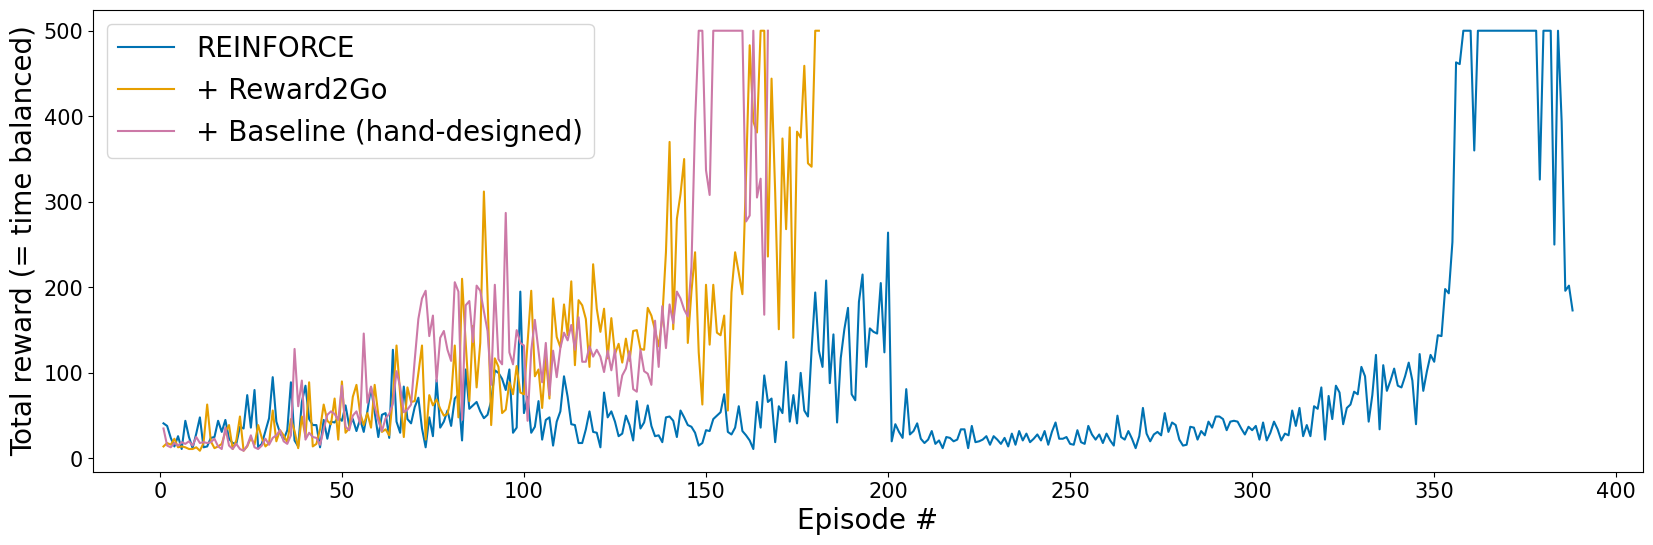

In [12]:
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Using color-blind friendly hex codes
ax.plot(
    np.arange(1, len(scores_vanilla) + 1),
    scores_vanilla,
    color="#0072B2",
    label="REINFORCE",
)
ax.plot(
    np.arange(1, len(scores_rwd2go) + 1),
    scores_rwd2go,
    color="#E69F00",
    label="+ Reward2Go",
)
ax.plot(
    np.arange(1, len(scores_baseline) + 1),
    scores_baseline,
    color="#CC79A7",
    label="+ Baseline (hand-designed)",
)

ax.set_ylabel("Total reward (= time balanced)", fontsize=20)
ax.set_xlabel("Episode #", fontsize=20)
ax.tick_params(axis="both", which="major", labelsize=15)
ax.legend(fontsize=20)

plt.show()

### Animate it with Video


In [13]:
# Local folder used to store videos
import os

drive_path = "./videos/"
os.makedirs(drive_path, exist_ok=True)

In [14]:
# If needed, replace drive_path by any local output folder.

In [15]:
# functions for creating the video
def show_video(env_name):
    mp4list = sorted(glob.glob(os.path.join(drive_path, f"{env_name}*.mp4")))
    if len(mp4list) > 0:
        mp4 = mp4list[-1]
        video = io.open(mp4, "r+b").read()
        encoded = base64.b64encode(video)
        display.display(HTML(data="""<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>""".format(encoded.decode("ascii"))))
    else:
        print("Could not find video")


def show_video_of_model(policy, env_name):
    env = gym.make(env_name, render_mode="rgb_array")
    env = RecordVideo(
        env,
        video_folder=drive_path,
        name_prefix=env_name,
        episode_trigger=lambda episode_id: True,
    )
    state, _ = env.reset()
    done = False
    for t in range(1000):
        action, _ = policy.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        if done:
            break
    env.close()

In [16]:
# sanity check for directory, if needed (onyl if using Colab)
# import os
# os.chdir('/content/drive/MyDrive/Colab Notebooks')
#!ls

In [17]:
# create video
policy = policy_vanilla  # policy_rwd2go, policy_baseline
show_video_of_model(policy_vanilla, "CartPole-v1")

c:\Users\horak\anaconda3\envs\imitlearn\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\horak\Documents\COURS_EPFL\RL\projet\EPFL_ReinforcementLearning\Cartpole\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [18]:
# show video
show_video("CartPole-v1")